<a href="https://colab.research.google.com/github/Terry4715/MVO-backtest/blob/main/MVO_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
%pip install yfinance
%pip install PyPortfolioOpt

SDKs

In [78]:
# Get data
import yfinance as yf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [79]:
# create a stock portfolio
symbols = ['AAPL', 'MSFT', 'META', 'AMZN', 'XOM', 'UNH', 'JNJ', 'V', 'HD', 'ABBV', 'KO', 'DIS', 'T', 'UPS', 'LMT', 'CAT', 'F', 'MAR', 'O', 'HSY']

In [80]:
# get portfolio data
data = yf.download(symbols, start='2021-03-31', end='2026-03-31')
data['Close'].head()

/tmp/ipykernel_1066/477952071.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  20 of 20 completed


Ticker,AAPL,ABBV,AMZN,CAT,DIS,F,HD,HSY,JNJ,KO,LMT,MAR,META,MSFT,O,T,UNH,UPS,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2021-03-31,118.864037,88.639107,154.703995,211.065781,180.274643,9.080655,268.123657,139.177963,141.902557,45.414127,320.736969,142.281143,292.236755,225.746429,47.331768,16.354572,341.514221,134.971161,203.663788,45.787289
2021-04-01,119.691177,88.884804,158.050003,211.857758,184.622253,9.021352,270.319641,139.705902,140.590179,45.241802,322.056274,142.434830,296.334503,232.046692,48.531815,16.462631,336.924896,135.995468,208.598358,47.066673
2021-04-05,122.513161,86.935440,161.336502,212.740707,184.163071,9.414228,277.039124,140.225113,141.108215,45.500294,328.766174,144.990097,306.504730,238.480972,48.636189,16.592299,339.779449,136.527420,210.695312,46.336773
2021-04-06,122.814819,86.312935,161.190994,209.946167,185.364761,9.577310,275.616150,141.465897,141.073685,45.827686,328.957153,145.652939,303.875366,237.322418,48.546726,16.738173,334.446686,137.337341,210.320129,46.205555
2021-04-07,124.459381,86.173714,163.969498,209.736816,183.244705,9.436468,274.465515,141.298706,141.263641,45.905231,330.016113,142.953568,310.652161,239.275696,48.859795,16.711161,335.612396,136.527420,210.916550,46.410587


In [81]:
# visualise cumulative returns of each portfolio holding
portfolio_returns = data['Close'].pct_change()

port_comps_rets_cumprod = portfolio_returns.add(1).cumprod().sub(1).multiply(100)

fig = px.line(port_comps_rets_cumprod,
              x=port_comps_rets_cumprod.index,
              y=port_comps_rets_cumprod.columns,
              title='5-Year Cumulative Returns')

fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Cumulative Returns %')

fig.show()

In [82]:
# import benchmark data and plot cum returns for comparison
bm_index = yf.download('^GSPC', start='2021-03-31', end='2026-03-31')
bm_index['Close'].head()

/tmp/ipykernel_1066/216105808.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2021-03-31,3972.889893
2021-04-01,4019.870117
2021-04-05,4077.909912
2021-04-06,4073.939941
2021-04-07,4079.949951


<Axes: xlabel='Ticker', ylabel='Ticker'>

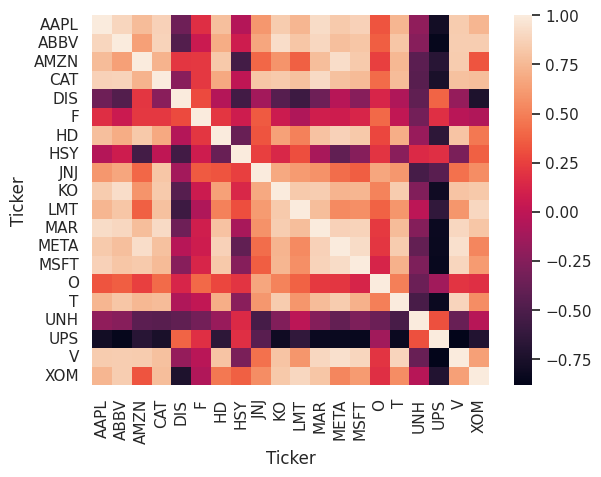

In [83]:
# creation correlation heatmap
port_corr = port_comps_rets_cumprod.corr()

sns.heatmap(port_corr)

In [84]:
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt.expected_returns import ema_historical_return
from pypfopt.risk_models import exp_cov
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.plotting import plot_efficient_frontier
from pypfopt.plotting import plot_weights
from pypfopt.cla import CLA

train = portfolio_returns[:'2024-03-30']
test = portfolio_returns['2024-03-31':]

mu = expected_returns.ema_historical_return(train, returns_data=True, span=500)
Sigma = risk_models.exp_cov(train, returns_data=True, span=180)

In [85]:
mu

,2024-03-28
Ticker,
AAPL,0.061651
ABBV,0.312173
AMZN,0.437980
CAT,0.580037
DIS,0.250055
F,0.221344
HD,0.269038
HSY,-0.028204
JNJ,0.014968


In [86]:
ret_ef = np.arange(0, 1.002519, 0.01)
vol_ef = []
for i in np.arange(0, 1.002519, 0.01):
  ef = EfficientFrontier(mu, Sigma)
  ef.efficient_return(i)
  vol_ef.append(ef.portfolio_performance()[1])

In [87]:
ef = EfficientFrontier(mu, Sigma)
ef.min_volatility()
min_vol_ret = ef.portfolio_performance()[0]
min_vol_vol = ef.portfolio_performance()[1]

In [88]:
ef = EfficientFrontier(mu, Sigma)
ef.max_sharpe(risk_free_rate=0.035)
max_sharpe_ret = ef.portfolio_performance()[0]
max_sharpe_vol = ef.portfolio_performance()[1]

/usr/local/lib/python3.12/dist-packages/pypfopt/efficient_frontier/efficient_frontier.py:441: UserWarning:

The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.



Text(0.5, 1.0, 'Efficient Frontier')

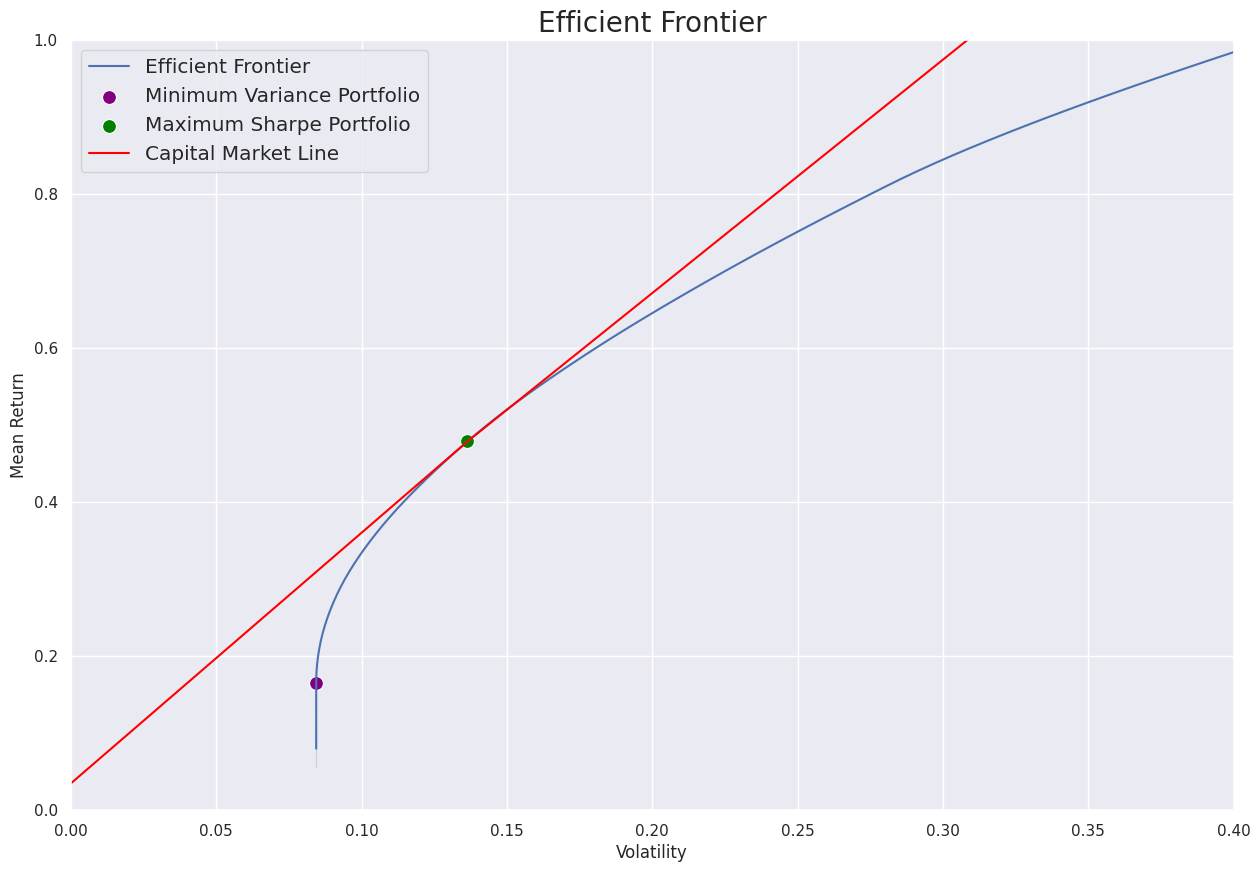

In [89]:
sns.set()

fig, ax = plt.subplots(figsize = [15,10])

sns.lineplot(x=vol_ef, y=ret_ef,
             label='Efficient Frontier',
             ax=ax)

sns.scatterplot(x=[min_vol_vol], y=[min_vol_ret],
                ax=ax,
                label='Minimum Variance Portfolio',
                color='purple', s=100)

sns.scatterplot(x=[max_sharpe_vol], y=[max_sharpe_ret],
                ax=ax,
                label='Maximum Sharpe Portfolio',
                color='green', s=100)

sns.lineplot(x=[0, max_sharpe_vol, 1], y=[0.035, max_sharpe_ret, 3.096],
             label='Capital Market Line',
             ax=ax,
             color='red')

ax.set(xlim = [0, 0.4])
ax.set(ylim = [0, 1])
ax.set_xlabel('Volatility')
ax.set_ylabel('Mean Return')
plt.legend(fontsize='large')
plt.title('Efficient Frontier', fontsize='20')

Expected annual return: 16.6%
Annual volatility: 8.4%
Sharpe Ratio: 1.55


(np.float64(0.16556449278643914),
 np.float64(0.08436393587918135),
 np.float64(1.5476339673556978))

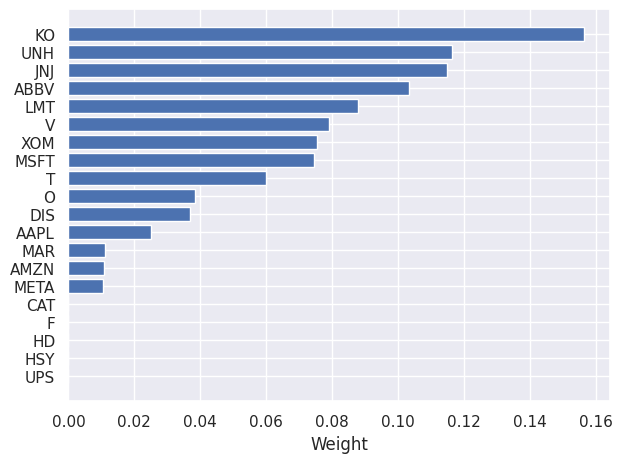

In [90]:
# Minimum Variance
ef = EfficientFrontier(mu, Sigma)
raw_weight_minvar_exp = ef.min_volatility()

plot_weights(raw_weight_minvar_exp)
ef.portfolio_performance(verbose=True, risk_free_rate=0.035)

Expected annual return: 47.9%
Annual volatility: 13.6%
Sharpe Ratio: 3.25


(np.float64(0.47890518748197664),
 np.float64(0.13639524861172794),
 np.float64(3.254550228106754))

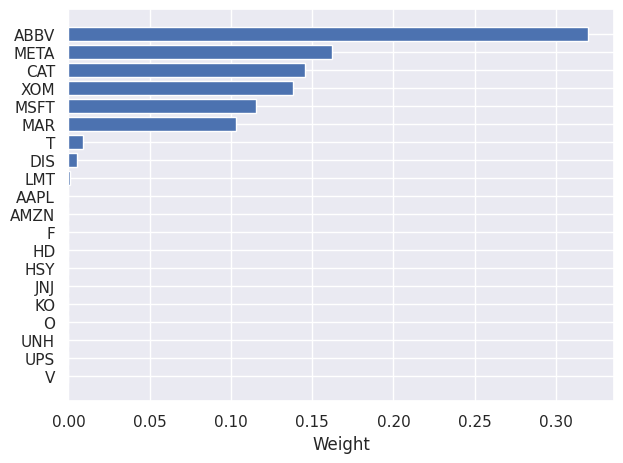

In [91]:
# Maximum Sharpe
ef = EfficientFrontier(mu, Sigma)
raw_weight_maxsharpe_exp = ef.max_sharpe(risk_free_rate=0.035)

plot_weights(raw_weight_maxsharpe_exp)
ef.portfolio_performance(verbose=True, risk_free_rate=0.035)

# Backtesting

In [92]:
weights_min_var_exp = list(raw_weight_minvar_exp.values())
weights_maxsharpe_exp = list(raw_weight_maxsharpe_exp.values())

ret_1 = test.dot(weights_min_var_exp).add(1).cumprod().subtract(1).multiply(100)
ret_2 = test.dot(weights_maxsharpe_exp).add(1).cumprod().subtract(1).multiply(100)

ind_ret = bm_index['Close']['2024-03-31':].pct_change().add(1).cumprod().subtract(1).multiply(100)

In [93]:
back = pd.DataFrame({'MinVar':ret_1, 'MaxSharpe':ret_2})
back = pd.concat([back, ind_ret], join='outer', axis=1)
back.drop(back.tail(1).index, inplace=True)

back.interpolate(method='linear', inplace=True)

fig = px.line(back, x=back.index, y=back.columns, title='Portfolio Performance')
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Cumulative Return %')

**Next step**: source asset class return expectations